In [11]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
from pathlib import Path

In [12]:
DATA_PATH = Path("../data/ArchiveII.csv")
SUBSAMPLED_PATH = Path("../results/ArchiveII_subsampled_ids.csv") 

full_ds = pd.read_csv(DATA_PATH) 
ss_ds = pd.read_csv(SUBSAMPLED_PATH)
ss_ds

,id,partition,fam
0,tmRNA_Ther.ther._Y15063_1-349,full,tmRNA
1,tmRNA_Shig.dyse._TRW-358708_1-363,full,tmRNA
2,tRNA_tdbR00000471-Oryctolagus_cuniculus-9986-V...,full,tRNA
3,srp_Caen.eleg._AY948608,full,srp
4,srp_Bruc.suis._AE014291,full,srp
...,...,...,...
15764,srp_Geob.kaus._BA000043,randS100,srp
15765,srp_Myco.pneu._AE000044,randS100,srp
15766,tmRNA_Ocea.ihey._BA000028_1-364,randS100,tmRNA
15767,srp_Desu.vulg._CP000527,randS100,srp


In [13]:
randS_100 = ss_ds.query("partition == 'randS100'")
randS_200 = ss_ds.query("partition == 'randS200'")
randS_400 = ss_ds.query("partition == 'randS400'")

dfs = [randS_100, randS_200, randS_400, full_ds ]
counts = [df.groupby("fam").size().reset_index(name="count").sort_values("count", ascending=False) for df in dfs] 

family_order = ['5s','23s', 'tmRNA','grp1','tRNA','16s','srp','RNaseP','telomerase']

sizes = np.array([df.shape[0] for df in dfs])  # Extract sizes from the dataframes
sizes_percent = sizes * 100 / dfs[-1].shape[0] # % of the full dataset


labels = [
    f"    100       \n ({sizes[0]} seqs)",
    f"    200       \n ({sizes[1]} seqs)",
    f"    400       \n ({sizes[2]} seqs)",
    f"    Full      \n ({sizes[3]} seqs)"
]
 

In [14]:
combined_counts = pd.DataFrame({"fam":[], "id":[], "dataset":[]})

for i, df in enumerate(dfs):
    count = df.groupby("fam")["id"].count().reset_index()
    count["dataset"] = labels[i]
    combined_counts = pd.concat([combined_counts, count], ignore_index=True) 
combined_counts

combined_counts
pivot_df = (
    combined_counts
    .pivot(index="dataset", columns="fam", values="id")
    .fillna(0)
)
pivot_df_percent = pivot_df.div(pivot_df.sum(axis=1), axis=0) * 100 

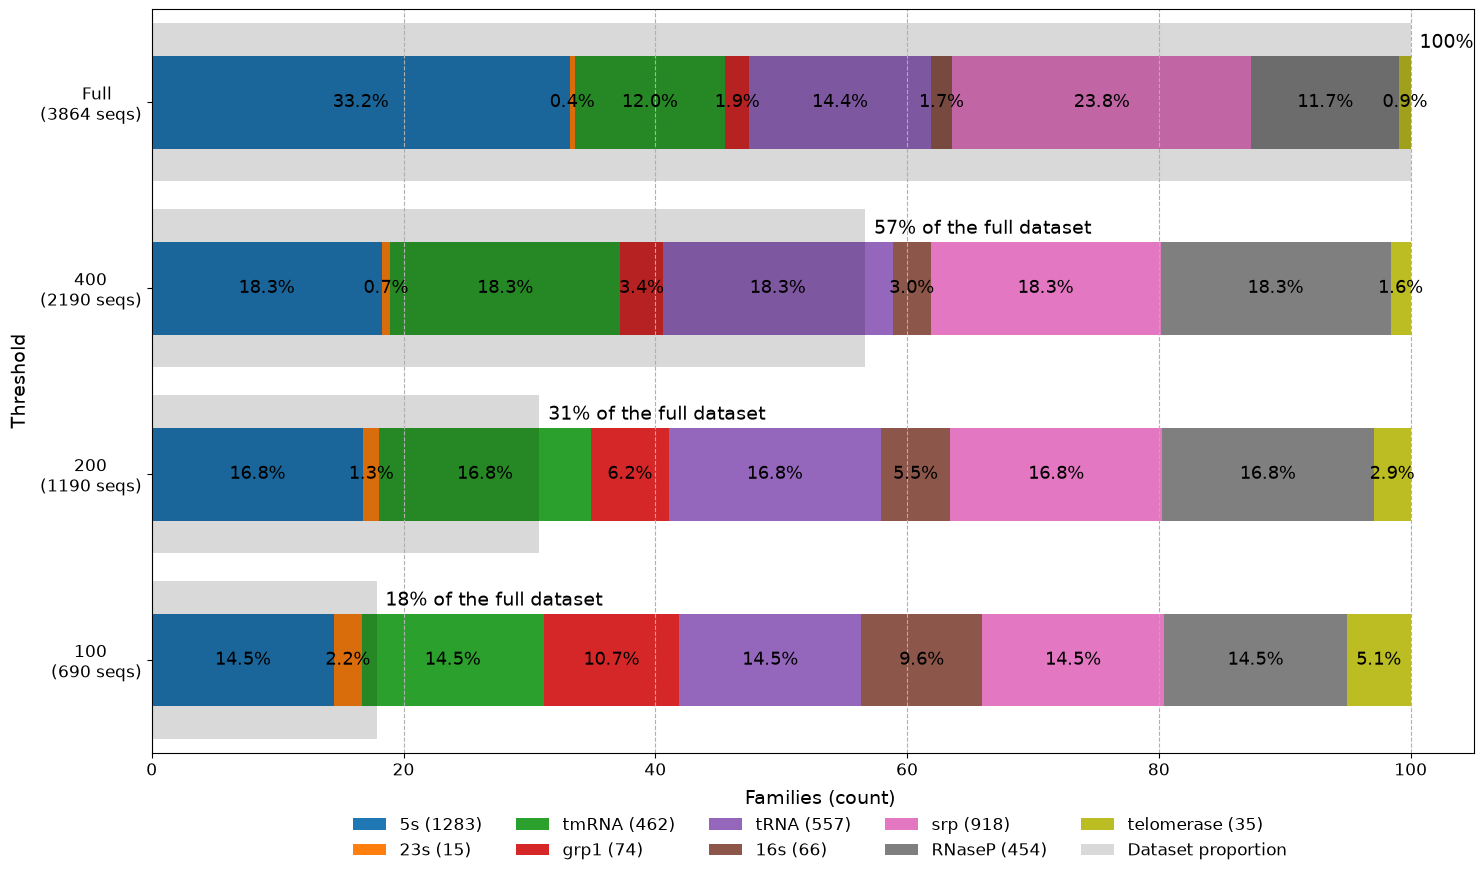

In [15]:
fig, ax = plt.subplots(figsize=(15, 8)) 
stacked = pivot_df_percent.loc[labels, family_order].plot(
    kind="barh",
    stacked=True,
    ax=ax,
    legend=False
)
for container in stacked.containers:
    stacked.bar_label(container, label_type="center", fmt="%.1f%%", fontsize=13)
y_positions = np.arange(len(labels))
 
bars_dataset = ax.barh(
    y_positions,
    sizes_percent,
    color="black",
    alpha=0.15,     
    height=0.85,    
    label="Dataset proportion"
)
 
for i, v in enumerate(sizes_percent):
    if v == 100:  
        ax.text(v + 0.7, i+0.32, f"{v:.0f}%", va='center', fontsize=14, color="black")
    else:
        ax.text(v + 0.7, i+0.32, f"{v:.0f}% of the full dataset", va='center', fontsize=14, color="black")

ax.set_ylabel("Threshold", fontsize=14)
ax.grid(axis="x", linestyle="--") 
ax.tick_params(axis="y", labelsize=12)
ax.tick_params(axis="x", labelsize=12)

handles, labels_legend = stacked.get_legend_handles_labels()
count_dict = {row["fam"]: row["id"] for _, row in count.iterrows()}
labels_legend = [f"{fam} ({count_dict[fam]})" if fam in family_order else fam for fam in labels_legend]

fig.legend(
    handles,
    labels_legend,
    title="Families (count)",
    bbox_to_anchor=(0.55, -0.1),
    loc="lower center",
    ncol=5,
    frameon=False,
    fontsize=12,
    title_fontsize=14
)

fig.tight_layout()
plt.show()
